# 🔩 Embedded Methods — Feature Selection

> **Folder:** `06_Feature_Selection`  
> **Notebook:** `embedded_methods.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand how **embedded methods** differ from filter and wrapper methods
- Use **Lasso (L1)** regularization for automatic feature selection
- Use **SelectFromModel** with tree-based feature importances
- Compare **MDI vs Permutation Importance** for Random Forest
- Apply **XGBoost / GradientBoosting** feature importance
- Use **ElasticNet** as a hybrid filter
- Compare all embedded methods on a unified leaderboard
- Build embedded selection correctly inside a **Pipeline**

---

## 📚 Techniques Covered

| # | Technique | Key Insight |
|---|-----------|-------------|
| 1 | Dataset Setup | High-dimensional classification + regression |
| 2 | Lasso (L1) Feature Selection | Shrinks irrelevant coefficients to exactly zero |
| 3 | LassoCV — Auto Alpha | CV-tuned Lasso for optimal sparsity |
| 4 | ElasticNet Selection | L1+L2 hybrid — groups correlated features |
| 5 | SelectFromModel | Unified API for any model with importances |
| 6 | Random Forest — MDI Importance | Mean Decrease in Impurity |
| 7 | Permutation Importance | Model-agnostic, corrects MDI bias |
| 8 | Gradient Boosting Importance | Boosting-based feature ranking |
| 9 | Embedded vs Filter vs Wrapper | Side-by-side comparison |
| 10 | Embedded in Pipeline | Correct leakage-free usage |
| 11 | Summary & Golden Rules | Key takeaways |


---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    Lasso, LassoCV, ElasticNet, ElasticNetCV,
    LogisticRegression, Ridge
)
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.feature_selection import (
    SelectFromModel, SelectKBest, f_classif,
    mutual_info_classif, RFE, VarianceThreshold
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    r2_score, mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 1️⃣ Dataset Setup

> Two synthetic datasets with **known informative features**:
> - **Classification**: 30 features, 8 truly informative
> - **Regression**: 20 features, 6 truly informative
>
> We use ground truth to verify whether each method correctly recovers informative features.


In [2]:
np.random.seed(42)

# ── Classification (30 features, 8 informative) ───────────────────────────
X_clf, y_clf = make_classification(
    n_samples=800, n_features=30, n_informative=8,
    n_redundant=10, n_repeated=0, n_classes=2,
    weights=[0.5, 0.5], flip_y=0.05, random_state=42
)
feat_names = [f'F{i+1:02d}' for i in range(30)]
X_clf_df   = pd.DataFrame(X_clf, columns=feat_names)
y_clf_s    = pd.Series(y_clf, name='Target')

# ── Regression (20 features, 6 informative) ───────────────────────────────
X_reg, y_reg = make_regression(
    n_samples=600, n_features=20, n_informative=6,
    noise=15, random_state=42
)
reg_names = [f'R{i+1:02d}' for i in range(20)]
X_reg_df  = pd.DataFrame(X_reg, columns=reg_names)
y_reg_s   = pd.Series(y_reg, name='Target')

# ── Scale + split ──────────────────────────────────────────────────────────
sc_clf = StandardScaler()
sc_reg = StandardScaler()

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf_df, y_clf_s, test_size=0.2, stratify=y_clf_s, random_state=42)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg_df, y_reg_s, test_size=0.2, random_state=42)

Xc_tr_sc = sc_clf.fit_transform(Xc_tr)
Xc_te_sc = sc_clf.transform(Xc_te)
Xr_tr_sc = sc_reg.fit_transform(Xr_tr)
Xr_te_sc = sc_reg.transform(Xr_te)

print(f'Classification : {X_clf_df.shape} | classes={dict(y_clf_s.value_counts().sort_index())}')
print(f'  Train={Xc_tr.shape}  Test={Xc_te.shape}')
print(f'Regression     : {X_reg_df.shape}')
print(f'  Train={Xr_tr.shape}  Test={Xr_te.shape}')
print()
print('Ground truth informative features:')
print('  Classification → F01–F08 (8 features)')
print('  Regression     → R01–R06 (6 features)')

Classification : (800, 30) | classes={0: 395, 1: 405}
  Train=(640, 30)  Test=(160, 30)
Regression     : (600, 20)
  Train=(480, 20)  Test=(120, 20)

Ground truth informative features:
  Classification → F01–F08 (8 features)
  Regression     → R01–R06 (6 features)


---
## 2️⃣ Lasso (L1) — Automatic Feature Selection via Regularization

> Lasso adds an **L1 penalty** to the loss function:
>
> `Loss = MSE + α × Σ|wⱼ|`
>
> L1 penalty has a special geometric property — it **shrinks some coefficients to exactly zero**,  
> effectively removing those features from the model.
>
> | α (alpha) | Effect |
> |:---------:|--------|
> | α → 0 | No regularization → all features kept |
> | α → ∞ | Heavy regularization → all coefficients = 0 |
> | Optimal α | Some coefficients = 0 → automatic feature selection |
>
> ✅ Lasso performs selection AND training in one step — no separate selector needed.


Lasso Feature Selection — Regression:
  alpha  Non-zero     R²    RMSE                                                                                           Selected
 0.0010        20 0.9911 13.4357 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
 0.0100        20 0.9911 13.4372 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
 0.0500        20 0.9911 13.4451 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
 0.1000        20 0.9911 13.4578 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
 0.5000        14 0.9909 13.5883                               R01, R02, R05, R06, R08, R09, R11, R12, R13, R14, R16, R17, R19, R20
 1.0000         8 0.9906 13.7878                                                             R01, R06, R09, R12, R16, R17, R19, R20
 5.0000         5 0.9841 17.9549      

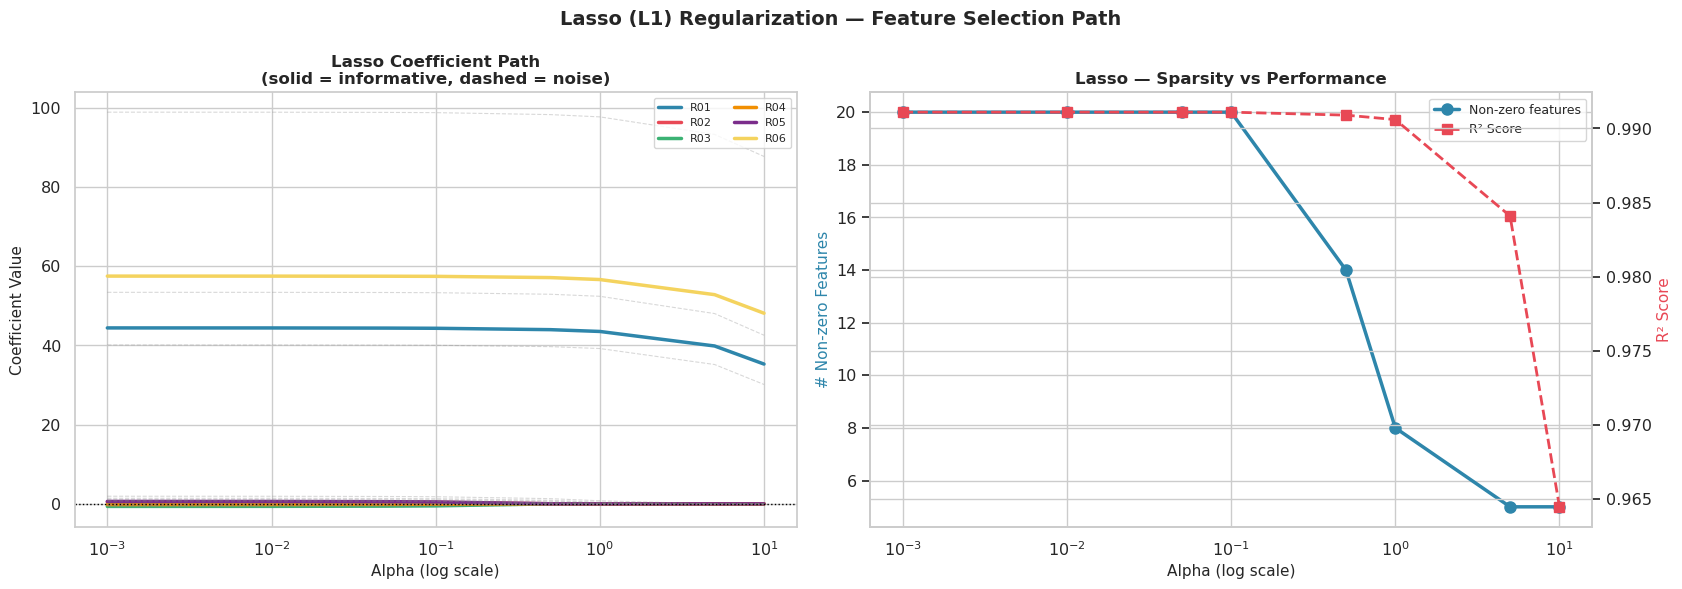

In [4]:
# ── Lasso for Regression ─────────────────────────────────────────────────
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(Xr_tr_sc, yr_tr)
    coefs        = lasso.coef_
    n_nonzero    = (coefs != 0).sum()
    selected     = np.array(reg_names)[coefs != 0].tolist()
    y_pred       = lasso.predict(Xr_te_sc)
    r2           = r2_score(yr_te, y_pred)
    rmse         = np.sqrt(mean_squared_error(yr_te, y_pred))
    lasso_results.append({
        'alpha'    : alpha,
        'Non-zero' : n_nonzero,
        'R²'       : round(r2, 4),
        'RMSE'     : round(rmse, 4),
        'Selected' : ', '.join(selected) if selected else '(none)',
    })

lasso_df = pd.DataFrame(lasso_results)
print('Lasso Feature Selection — Regression:')
print(lasso_df[['alpha','Non-zero','R²','RMSE','Selected']].to_string(index=False))

# Coefficient path plot
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

coef_paths = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(Xr_tr_sc, yr_tr)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)
for j, name in enumerate(reg_names):
    style      = '-'   if j < 6 else '--'
    lw         = 2.5   if j < 6 else 0.8
    alpha_line = 1.0   if j < 6 else 0.3
    color      = COLORS['palette'][j % 6] if j < 6 else 'gray'
    axes[0].plot(alphas, coef_paths[:, j], style,
                 color=color, linewidth=lw, alpha=alpha_line,
                 label=name if j < 6 else None)

axes[0].axhline(0, color='black', linewidth=1, linestyle=':')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)', fontsize=11)
axes[0].set_ylabel('Coefficient Value', fontsize=11)
axes[0].set_title('Lasso Coefficient Path\n(solid = informative, dashed = noise)',  # ← fix here
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)

# Non-zero features vs alpha
ax2 = axes[1].twinx()
axes[1].plot(lasso_df['alpha'], lasso_df['Non-zero'], 'o-',
             color=COLORS['primary'], linewidth=2.5, markersize=8,
             label='Non-zero features')
ax2.plot(lasso_df['alpha'], lasso_df['R²'], 's--',
         color=COLORS['secondary'], linewidth=2, markersize=7,
         label='R² Score')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)', fontsize=11)
axes[1].set_ylabel('# Non-zero Features', fontsize=11, color=COLORS['primary'])
ax2.set_ylabel('R² Score', fontsize=11, color=COLORS['secondary'])
axes[1].set_title('Lasso — Sparsity vs Performance', fontsize=12, fontweight='bold')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.suptitle('Lasso (L1) Regularization — Feature Selection Path',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ LassoCV — Auto-Select Optimal Alpha via Cross-Validation

> `LassoCV` automatically finds the **optimal alpha** via cross-validation  
> — no need to manually search over alpha values.
>
> ✅ Always prefer `LassoCV` over `Lasso` with manual alpha tuning.


LassoCV Results:
  Best alpha      : 0.432876
  Non-zero coefs  : 15 / 20
  Selected        : ['R01', 'R02', 'R03', 'R05', 'R06', 'R08', 'R09', 'R11', 'R12', 'R13', 'R14', 'R16', 'R17', 'R19', 'R20']
  Test R²         : 0.9910


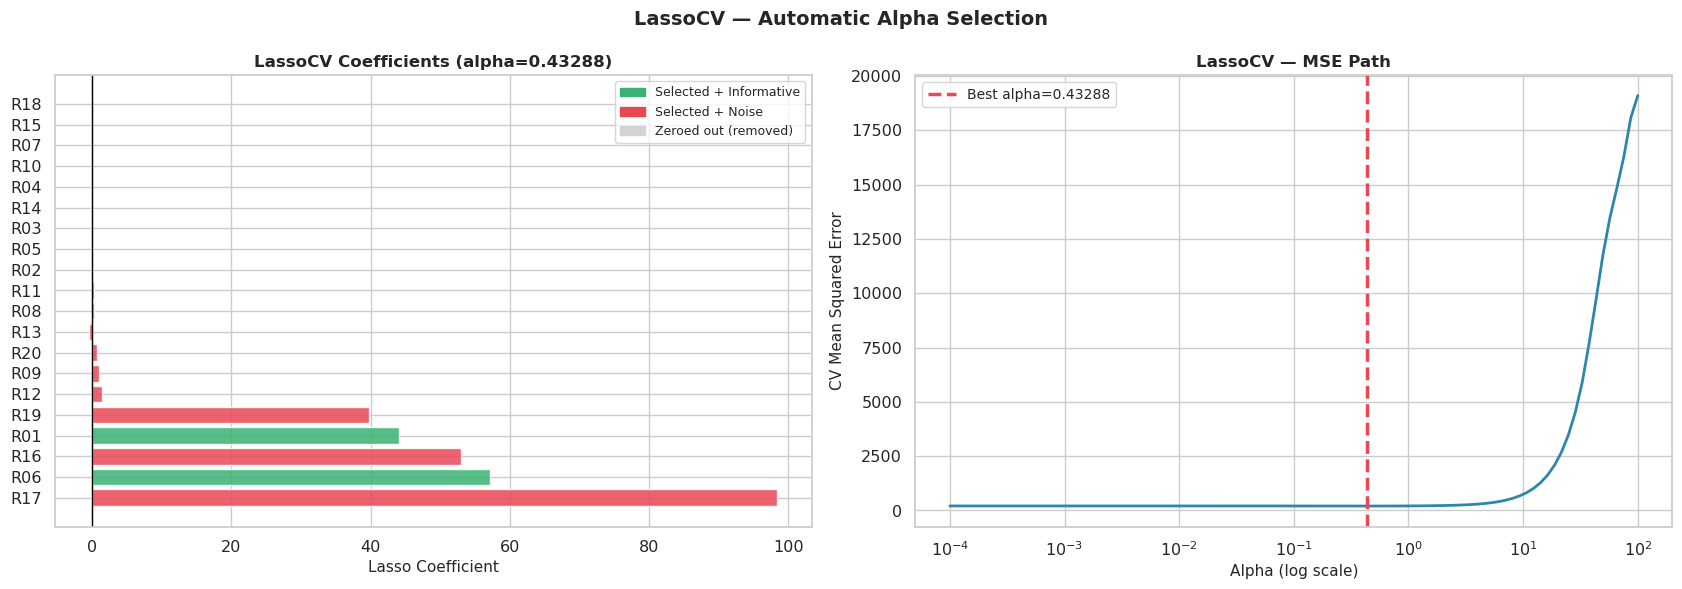

In [5]:
# ── LassoCV on Regression ─────────────────────────────────────────────────
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 2, 100),
    cv=5,
    max_iter=10000,
    random_state=42,
    n_jobs=-1,
)
lasso_cv.fit(Xr_tr_sc, yr_tr)

best_alpha   = lasso_cv.alpha_
coefs_cv     = lasso_cv.coef_
n_nonzero_cv = (coefs_cv != 0).sum()
selected_cv  = np.array(reg_names)[coefs_cv != 0].tolist()
r2_cv        = r2_score(yr_te, lasso_cv.predict(Xr_te_sc))

print(f'LassoCV Results:')
print(f'  Best alpha      : {best_alpha:.6f}')
print(f'  Non-zero coefs  : {n_nonzero_cv} / {len(reg_names)}')
print(f'  Selected        : {selected_cv}')
print(f'  Test R²         : {r2_cv:.4f}')

# Coefficient bar chart
coef_df = pd.DataFrame({
    'Feature'    : reg_names,
    'Coefficient': coefs_cv,
    'Informative': [i < 6 for i in range(len(reg_names))],
}).sort_values('Coefficient', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

bar_colors = [COLORS['accent'] if abs(c) > 0 and inf else
              COLORS['secondary'] if abs(c) > 0 else 'lightgray'
              for c, inf in zip(coef_df['Coefficient'], coef_df['Informative'])]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Lasso Coefficient', fontsize=11)
axes[0].set_title(f'LassoCV Coefficients (alpha={best_alpha:.5f})',
                  fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color=COLORS['accent'],    label='Selected + Informative'),
    Patch(color=COLORS['secondary'], label='Selected + Noise'),
    Patch(color='lightgray',         label='Zeroed out (removed)'),
], fontsize=9)

# CV mean squared error path
mse_path = lasso_cv.mse_path_.mean(axis=1)
axes[1].plot(lasso_cv.alphas_, mse_path, color=COLORS['primary'], linewidth=2)
axes[1].axvline(best_alpha, color=COLORS['secondary'], linestyle='--',
                linewidth=2.5, label=f'Best alpha={best_alpha:.5f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)', fontsize=11)
axes[1].set_ylabel('CV Mean Squared Error', fontsize=11)
axes[1].set_title('LassoCV — MSE Path', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('LassoCV — Automatic Alpha Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ ElasticNet — L1 + L2 Hybrid Selection

> ElasticNet combines L1 (sparsity) and L2 (grouping) penalties:
>
> `Loss = MSE + α × l1_ratio × Σ|wⱼ| + α × (1−l1_ratio)/2 × Σwⱼ²`
>
> | l1_ratio | Behavior |
> |:--------:|----------|
> | 1.0 | Pure Lasso — maximum sparsity |
> | 0.0 | Pure Ridge — no sparsity |
> | 0.5 | Balanced — groups correlated features |
>
> ✅ Preferred over Lasso when features are highly correlated —  
>    Lasso arbitrarily picks one from a correlated group; ElasticNet keeps all.


ElasticNet CV Results across l1_ratio:
 l1_ratio  Best alpha  Non-zero     R²                                                                                           Selected
   0.1000      0.0003        20 0.9911 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
   0.3000      0.0007        20 0.9911 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
   0.5000      0.0013        20 0.9911 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
   0.7000      0.0034        20 0.9911 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
   0.9000      0.0222        20 0.9911 R01, R02, R03, R04, R05, R06, R07, R08, R09, R10, R11, R12, R13, R14, R15, R16, R17, R18, R19, R20
   1.0000      0.4715        15 0.9909                          R01, R02, R03, R05, R06, R08, R09, R11, R12, R13, R14, R16, R17, R19,

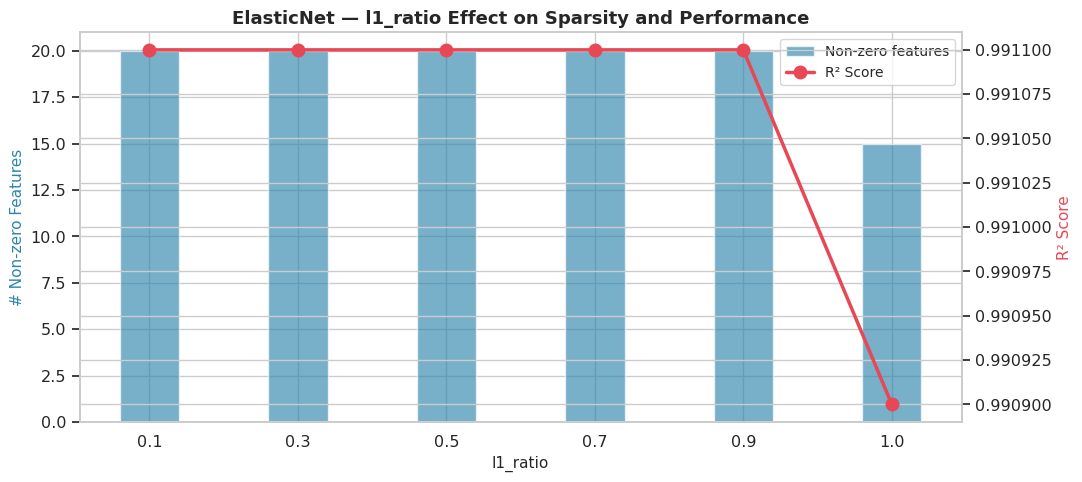

In [6]:
# ── ElasticNetCV ──────────────────────────────────────────────────────────
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
en_results = []

for l1r in l1_ratios:
    en_cv = ElasticNetCV(
        l1_ratio=l1r,
        alphas=np.logspace(-4, 1, 50),
        cv=5, max_iter=10000, random_state=42, n_jobs=-1
    )
    en_cv.fit(Xr_tr_sc, yr_tr)
    coefs    = en_cv.coef_
    n_nz     = (coefs != 0).sum()
    r2_en    = r2_score(yr_te, en_cv.predict(Xr_te_sc))
    selected = np.array(reg_names)[coefs != 0].tolist()
    en_results.append({
        'l1_ratio'  : l1r,
        'Best alpha': round(en_cv.alpha_, 5),
        'Non-zero'  : n_nz,
        'R²'        : round(r2_en, 4),
        'Selected'  : ', '.join(selected),
    })

en_df = pd.DataFrame(en_results)
print('ElasticNet CV Results across l1_ratio:')
print(en_df.to_string(index=False))

# Plot non-zero vs R² by l1_ratio
fig, ax = plt.subplots(figsize=(11, 5))
ax2 = ax.twinx()
ax.bar(en_df['l1_ratio'].astype(str), en_df['Non-zero'],
       color=COLORS['primary'], alpha=0.65, width=0.4, label='Non-zero features')
ax2.plot(en_df['l1_ratio'].astype(str), en_df['R²'], 'o-',
         color=COLORS['secondary'], linewidth=2.5, markersize=9, label='R² Score')
ax.set_xlabel('l1_ratio', fontsize=11)
ax.set_ylabel('# Non-zero Features', fontsize=11, color=COLORS['primary'])
ax2.set_ylabel('R² Score', fontsize=11, color=COLORS['secondary'])
ax.set_title('ElasticNet — l1_ratio Effect on Sparsity and Performance',
             fontsize=13, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=10)
plt.tight_layout()
plt.show()

---
## 5️⃣ SelectFromModel — Unified API for Any Model

> `SelectFromModel` is a sklearn wrapper that selects features based on  
> any model's `coef_` or `feature_importances_` attribute.
>
> Works with: **Lasso, Ridge, LogisticRegression, RandomForest, XGBoost, GradientBoosting**
>
> ```python
> sel = SelectFromModel(estimator, threshold='mean')
> # threshold options:
> #   'mean'   → keep features above mean importance
> #   'median' → keep features above median importance
> #   float    → keep features above this absolute value
> #   '1.25*mean' → keep features above 1.25× mean importance
> ```


In [7]:
# ── SelectFromModel with different estimators ─────────────────────────────
sfm_configs = [
    ('Lasso (regression)',
     SelectFromModel(Lasso(alpha=best_alpha, max_iter=10000), threshold=1e-5),
     Xr_tr_sc, Xr_te_sc, yr_tr, yr_te, reg_names, 'regression'),

    ('LogReg L1 (classification)',
     SelectFromModel(LogisticRegression(penalty='l1', C=0.5,
                                         solver='liblinear', max_iter=1000)),
     Xc_tr_sc, Xc_te_sc, yc_tr, yc_te, feat_names, 'classification'),

    ('Random Forest (classification)',
     SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42),
                     threshold='mean'),
     Xc_tr_sc, Xc_te_sc, yc_tr, yc_te, feat_names, 'classification'),

    ('GradientBoosting (classification)',
     SelectFromModel(GradientBoostingClassifier(n_estimators=100, random_state=42),
                     threshold='mean'),
     Xc_tr_sc, Xc_te_sc, yc_tr, yc_te, feat_names, 'classification'),
]

sfm_results = []
for name, sfm, Xtr, Xte, ytr, yte, fnames, task in sfm_configs:
    sfm.fit(Xtr, ytr)
    X_tr_sel = sfm.transform(Xtr)
    X_te_sel = sfm.transform(Xte)
    selected = np.array(fnames)[sfm.get_support()].tolist()
    k_sel    = len(selected)

    if task == 'classification':
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_tr_sel, ytr)
        score = roc_auc_score(yte, model.predict_proba(X_te_sel)[:,1])
        metric = 'ROC-AUC'
    else:
        model = Ridge()
        model.fit(X_tr_sel, ytr)
        score = r2_score(yte, model.predict(X_te_sel))
        metric = 'R²'

    sfm_results.append({
        'Estimator' : name,
        'k selected': k_sel,
        metric      : round(score, 4),
        'Features'  : ', '.join(selected[:8]) + ('...' if k_sel > 8 else ''),
    })
    print(f'  {name}: k={k_sel} | {metric}={score:.4f} | {selected}')

sfm_df = pd.DataFrame(sfm_results)
print('\nSelectFromModel Summary:')
print(sfm_df[['Estimator','k selected']].to_string(index=False))

  Lasso (regression): k=15 | R²=0.9911 | ['R01', 'R02', 'R03', 'R05', 'R06', 'R08', 'R09', 'R11', 'R12', 'R13', 'R14', 'R16', 'R17', 'R19', 'R20']
  LogReg L1 (classification): k=19 | ROC-AUC=0.8001 | ['F01', 'F02', 'F03', 'F04', 'F05', 'F08', 'F10', 'F13', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F26', 'F29', 'F30']
  Random Forest (classification): k=11 | ROC-AUC=0.8158 | ['F03', 'F05', 'F06', 'F07', 'F10', 'F11', 'F14', 'F18', 'F19', 'F21', 'F28']
  GradientBoosting (classification): k=7 | ROC-AUC=0.8100 | ['F03', 'F06', 'F07', 'F10', 'F11', 'F19', 'F21']

SelectFromModel Summary:
                        Estimator  k selected
               Lasso (regression)          15
       LogReg L1 (classification)          19
   Random Forest (classification)          11
GradientBoosting (classification)           7


---
## 6️⃣ Random Forest — MDI Feature Importance

> Random Forest provides **Mean Decrease in Impurity (MDI)** importance:  
> how much each feature reduces impurity (Gini/entropy) across all trees.
>
> ⚠️ MDI has known biases:
> - **Favors high-cardinality features** (many unique values)
> - **Inflated for correlated features** — both get partial credit
> - **Not reliable for noisy or collinear features**
>
> ✅ Use **Permutation Importance** to correct these biases (next cell).


RF MDI Importance — Top 15:
 Rank Feature  MDI Imp  Informative  Cum Imp
    1     F10   0.1358        False   0.1358
    2     F06   0.0825         True   0.2183
    3     F07   0.0783         True   0.2966
    4     F03   0.0638         True   0.3604
    5     F05   0.0525         True   0.4129
    6     F21   0.0516        False   0.4645
    7     F19   0.0446        False   0.5091
    8     F11   0.0414        False   0.5504
    9     F18   0.0393        False   0.5897
   10     F14   0.0373        False   0.6270
   11     F24   0.0311        False   0.6581
   12     F16   0.0305        False   0.6886
   13     F09   0.0300        False   0.7186
   14     F28   0.0296        False   0.7482
   15     F12   0.0233        False   0.7715


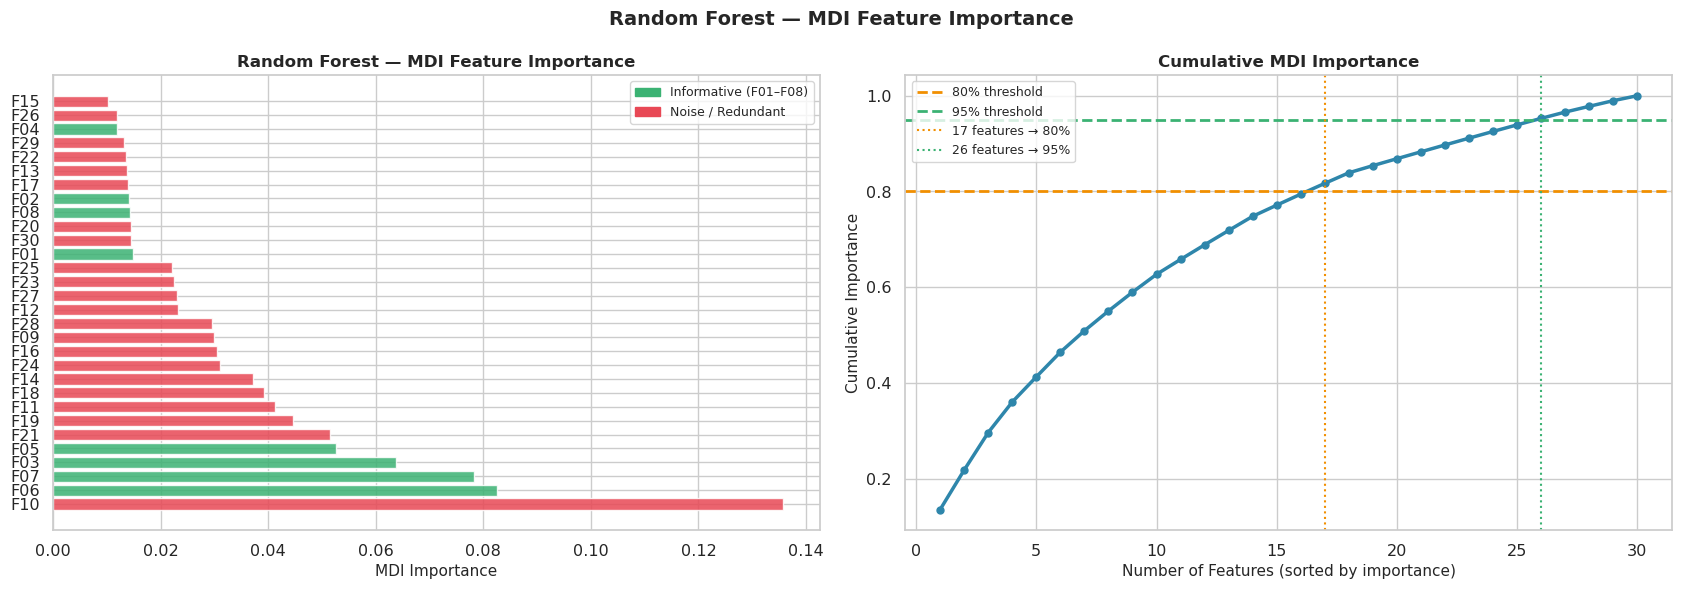

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(Xc_tr_sc, yc_tr)

mdi_imp = pd.DataFrame({
    'Feature'   : feat_names,
    'MDI Imp'   : rf.feature_importances_,
    'Informative': [i < 8 for i in range(30)],
}).sort_values('MDI Imp', ascending=False).reset_index(drop=True)

mdi_imp['Rank']    = mdi_imp.index + 1
mdi_imp['Cum Imp'] = mdi_imp['MDI Imp'].cumsum().round(4)

print('RF MDI Importance — Top 15:')
print(mdi_imp.head(15)[['Rank','Feature','MDI Imp','Informative','Cum Imp']].to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

bar_colors = [COLORS['accent'] if inf else COLORS['secondary']
              for inf in mdi_imp['Informative']]
axes[0].barh(mdi_imp['Feature'], mdi_imp['MDI Imp'],
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('MDI Importance', fontsize=11)
axes[0].set_title('Random Forest — MDI Feature Importance',
                  fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color=COLORS['accent'],    label='Informative (F01–F08)'),
    Patch(color=COLORS['secondary'], label='Noise / Redundant'),
], fontsize=9)

# Cumulative importance
axes[1].plot(range(1, len(mdi_imp)+1), mdi_imp['Cum Imp'],
             'o-', color=COLORS['primary'], linewidth=2.5, markersize=5)
axes[1].axhline(0.80, color=COLORS['warning'], linestyle='--',
                linewidth=2, label='80% threshold')
axes[1].axhline(0.95, color=COLORS['accent'], linestyle='--',
                linewidth=2, label='95% threshold')
k80 = (mdi_imp['Cum Imp'] >= 0.80).idxmax() + 1
k95 = (mdi_imp['Cum Imp'] >= 0.95).idxmax() + 1
axes[1].axvline(k80, color=COLORS['warning'], linestyle=':', linewidth=1.5,
                label=f'{k80} features → 80%')
axes[1].axvline(k95, color=COLORS['accent'],  linestyle=':', linewidth=1.5,
                label=f'{k95} features → 95%')
axes[1].set_xlabel('Number of Features (sorted by importance)', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative MDI Importance', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Random Forest — MDI Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Permutation Importance — Correcting MDI Bias

> Permutation Importance shuffles each feature's values and measures  
> how much the model's performance **drops**:
>
> ```
> For each feature j:
>   1. Randomly permute (shuffle) column j in the test set
>   2. Score the model on the permuted data
>   3. Importance = original_score − permuted_score
>
> High importance → shuffling this feature hurts performance a lot
> Low importance  → shuffling this feature barely matters → remove it
> ```
>
> ✅ Works with ANY model (model-agnostic)  
> ✅ Corrects MDI bias for correlated/high-cardinality features  
> ⚠️ Slower — requires re-scoring n_repeats times per feature


Permutation Importance — Top 15:
Feature  Perm Mean  Perm Std  Informative
    F10     0.0538    0.0131        False
    F03     0.0247    0.0066         True
    F07     0.0185    0.0068         True
    F06     0.0115    0.0059         True
    F11     0.0110    0.0038        False
    F21     0.0084    0.0055        False
    F14     0.0068    0.0021        False
    F19     0.0063    0.0043        False
    F18     0.0046    0.0040        False
    F16     0.0040    0.0036        False
    F25     0.0025    0.0016        False
    F05     0.0025    0.0032         True
    F09     0.0023    0.0019        False
    F01     0.0018    0.0008         True
    F12     0.0015    0.0012        False


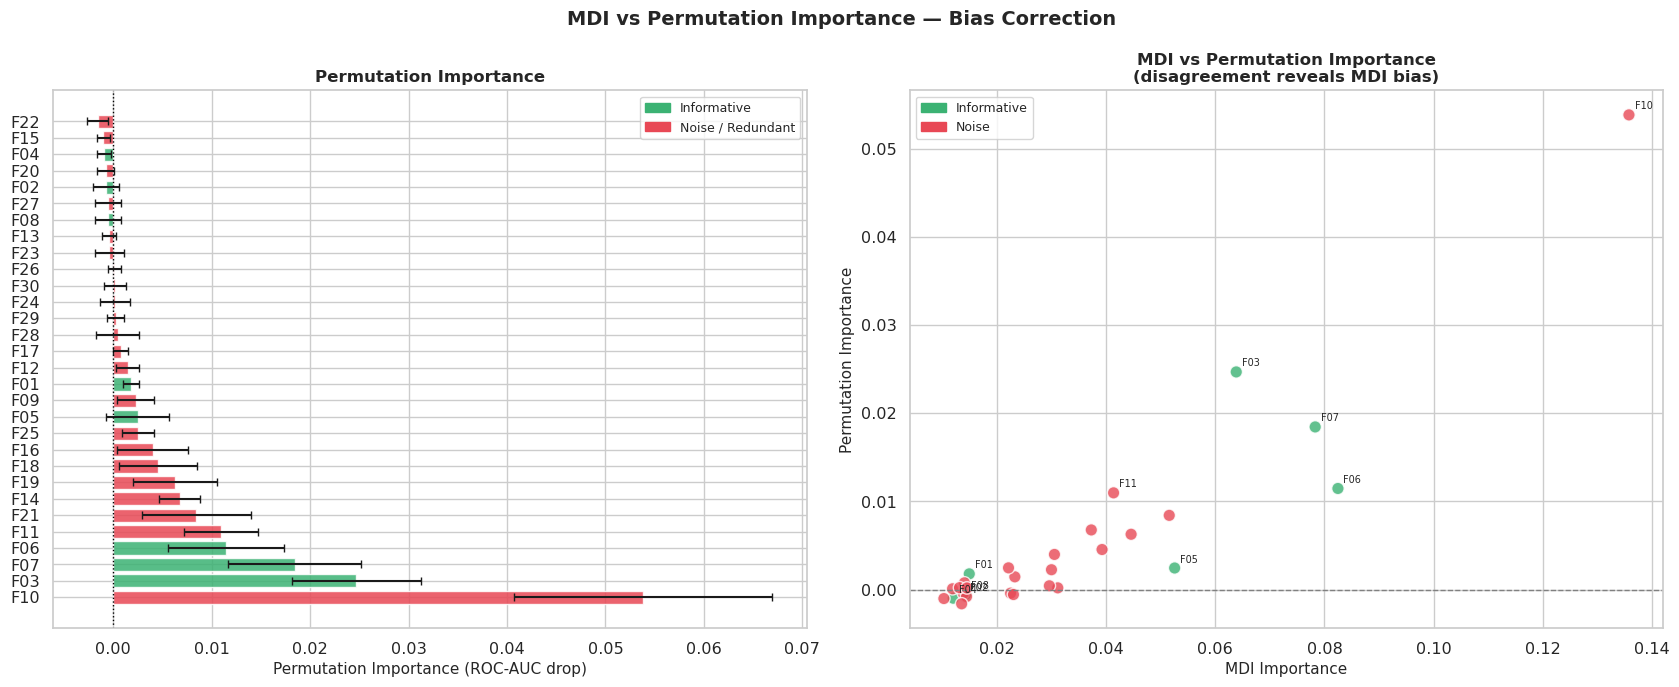

In [10]:
result = permutation_importance(
    rf, Xc_te_sc, yc_te,
    n_repeats=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
)

perm_imp = pd.DataFrame({
    'Feature'    : feat_names,
    'Perm Mean'  : result.importances_mean,
    'Perm Std'   : result.importances_std,
    'Informative': [i < 8 for i in range(30)],
}).sort_values('Perm Mean', ascending=False).reset_index(drop=True)

print('Permutation Importance — Top 15:')
print(perm_imp.head(15)[['Feature','Perm Mean','Perm Std','Informative']].round(4).to_string(index=False))

# MDI vs Permutation side by side
mdi_sorted  = mdi_imp.set_index('Feature')['MDI Imp']
perm_sorted = perm_imp.set_index('Feature')['Perm Mean']

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Permutation
bar_colors_p = [COLORS['accent'] if inf else COLORS['secondary']
                for inf in perm_imp['Informative']]
axes[0].barh(perm_imp['Feature'], perm_imp['Perm Mean'],
             xerr=perm_imp['Perm Std'], color=bar_colors_p,
             alpha=0.85, edgecolor='white', capsize=3)
axes[0].axvline(0, color='black', linewidth=1, linestyle=':')
axes[0].set_xlabel('Permutation Importance (ROC-AUC drop)', fontsize=11)
axes[0].set_title('Permutation Importance', fontsize=12, fontweight='bold')
axes[0].legend(handles=[
    Patch(color=COLORS['accent'],    label='Informative'),
    Patch(color=COLORS['secondary'], label='Noise / Redundant'),
], fontsize=9)

# Scatter: MDI vs Permutation
common    = [f for f in feat_names]
mdi_vals  = [mdi_sorted.get(f, 0)  for f in common]
perm_vals = [perm_sorted.get(f, 0) for f in common]
inf_mask  = [i < 8 for i in range(len(common))]

colors_sc = [COLORS['accent'] if inf else COLORS['secondary'] for inf in inf_mask]
axes[1].scatter(mdi_vals, perm_vals, c=colors_sc, s=80, alpha=0.8, edgecolors='white')
for i, f in enumerate(common):
    if inf_mask[i] or abs(perm_vals[i]) > 0.01:
        axes[1].annotate(f, (mdi_vals[i], perm_vals[i]),
                         textcoords='offset points', xytext=(4,4), fontsize=7)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('MDI Importance', fontsize=11)
axes[1].set_ylabel('Permutation Importance', fontsize=11)
axes[1].set_title('MDI vs Permutation Importance\n(disagreement reveals MDI bias)',  # ← fix here
                  fontsize=12, fontweight='bold')
axes[1].legend(handles=[
    Patch(color=COLORS['accent'],    label='Informative'),
    Patch(color=COLORS['secondary'], label='Noise'),
], fontsize=9)

plt.suptitle('MDI vs Permutation Importance — Bias Correction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Gradient Boosting Feature Importance

> GradientBoosting also provides feature importances via MDI (like RF),  
> but boosting focuses on **hard-to-predict samples** — giving different  
> emphasis than Random Forest bagging.
>
> XGBoost additionally provides:
> - `weight` — number of times feature used in splits
> - `gain`   — average gain of splits using this feature ← most reliable
> - `cover`  — average coverage of splits


Feature Importance Comparison — RF MDI vs GB MDI vs Permutation:
Feature  RF MDI  GB MDI  Perm Imp  Informative
    F10  0.1358  0.2491    0.0538        False
    F03  0.0638  0.1537    0.0247         True
    F07  0.0783  0.1338    0.0185         True
    F19  0.0446  0.0733    0.0063        False
    F11  0.0414  0.0645    0.0110        False
    F06  0.0825  0.0586    0.0115         True
    F27  0.0230  0.0457   -0.0005        False
    F21  0.0516  0.0324    0.0084        False
    F05  0.0525  0.0276    0.0025         True
    F09  0.0300  0.0243    0.0023        False
    F12  0.0233  0.0160    0.0015        False
    F18  0.0393  0.0141    0.0046        False
    F16  0.0305  0.0135    0.0040        False
    F22  0.0135  0.0108   -0.0016        False
    F02  0.0141  0.0095   -0.0007         True


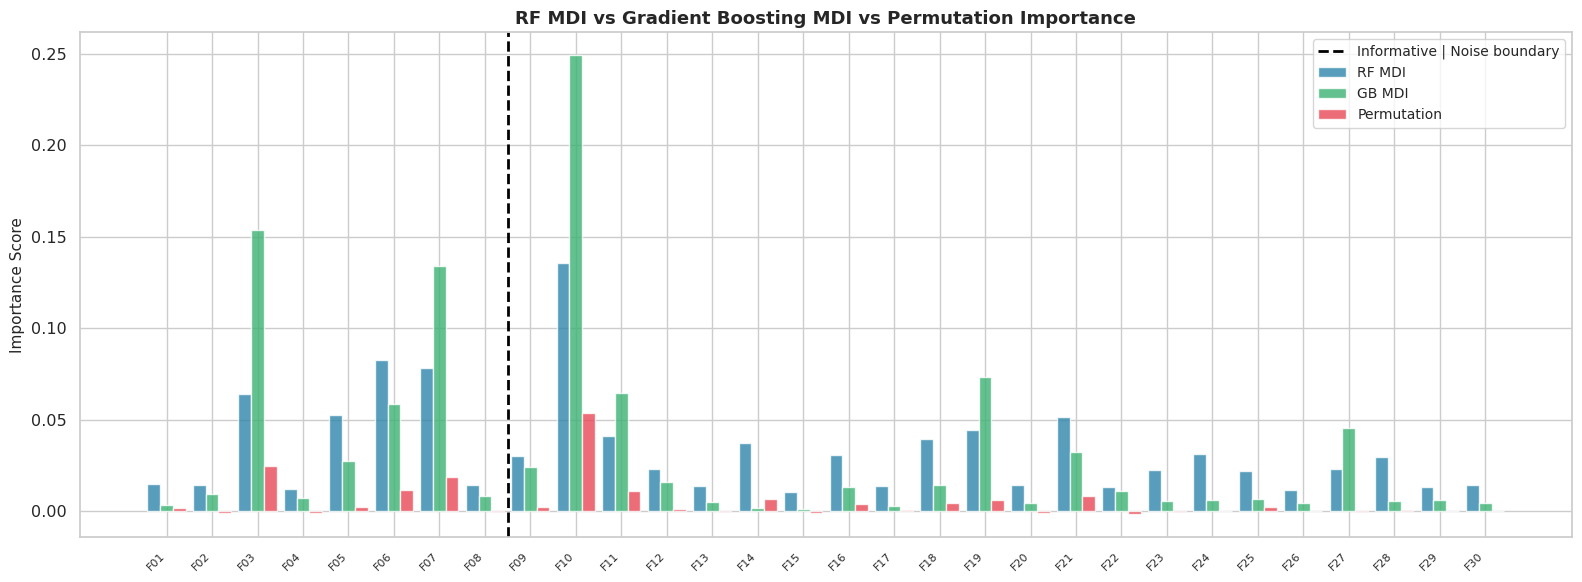

In [11]:
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42
)
gb.fit(Xc_tr_sc, yc_tr)

gb_imp = pd.DataFrame({
    'Feature'    : feat_names,
    'GB Imp'     : gb.feature_importances_,
    'Informative': [i < 8 for i in range(30)],
}).sort_values('GB Imp', ascending=False).reset_index(drop=True)

# Compare RF MDI vs GB MDI
compare_imp = pd.DataFrame({
    'Feature'    : feat_names,
    'RF MDI'     : rf.feature_importances_,
    'GB MDI'     : gb.feature_importances_,
    'Perm Imp'   : result.importances_mean,
    'Informative': [i < 8 for i in range(30)],
}).sort_values('GB MDI', ascending=False).reset_index(drop=True)

print('Feature Importance Comparison — RF MDI vs GB MDI vs Permutation:')
print(compare_imp.head(15).round(4).to_string(index=False))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(16, 6))
x      = np.arange(len(feat_names))
width  = 0.28

ax.bar(x - width, compare_imp.set_index('Feature').loc[feat_names,'RF MDI'],
       width, label='RF MDI', color=COLORS['primary'], alpha=0.8)
ax.bar(x,         compare_imp.set_index('Feature').loc[feat_names,'GB MDI'],
       width, label='GB MDI', color=COLORS['accent'], alpha=0.8)
ax.bar(x + width, compare_imp.set_index('Feature').loc[feat_names,'Perm Imp'],
       width, label='Permutation', color=COLORS['secondary'], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.axvline(7.5, color='black', linestyle='--', linewidth=2,
           label='Informative | Noise boundary')
ax.set_ylabel('Importance Score', fontsize=11)
ax.set_title('RF MDI vs Gradient Boosting MDI vs Permutation Importance',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 9️⃣ Embedded vs Filter vs Wrapper — Unified Comparison

> Comparing all three method families on the same dataset:  
> which method best recovers the 8 truly informative features?


Feature Recovery Comparison (k=8, true informative = F01–F08):
               Method Recovered  False Alarms  Test ROC-AUC
      Filter: ANOVA F       3/8             5        0.8186
  Filter: Mutual Info       4/8             4        0.8115
         Wrapper: RFE       2/8             6        0.8170
    Embedded: L1 (LR)       2/8             6        0.8101
     Embedded: RF MDI       4/8             4        0.8137
Embedded: Permutation       3/8             5        0.8109


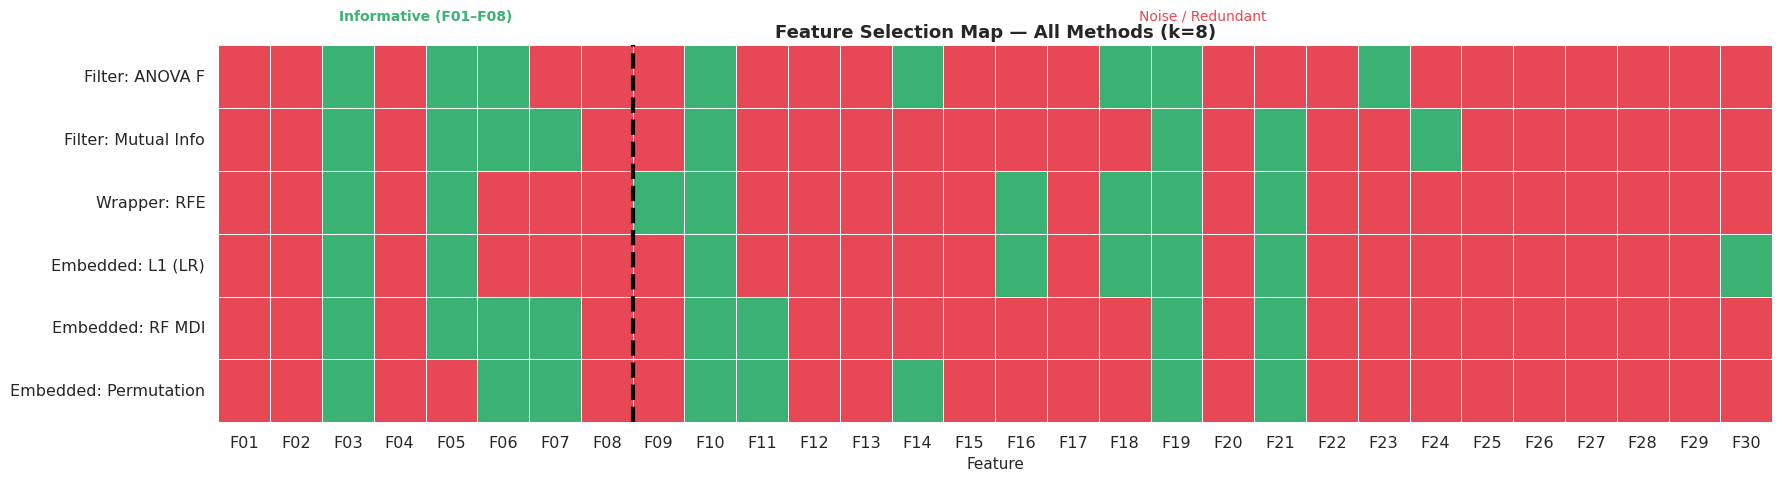

In [12]:
k = 8

# ── All methods ───────────────────────────────────────────────────────────
# Filter: ANOVA F
skb_f = SelectKBest(f_classif, k=k)
skb_f.fit(Xc_tr_sc, yc_tr)
filter_anova = set(np.array(feat_names)[skb_f.get_support()])

# Filter: Mutual Information
skb_mi = SelectKBest(mutual_info_classif, k=k)
skb_mi.fit(Xc_tr_sc, yc_tr)
filter_mi = set(np.array(feat_names)[skb_mi.get_support()])

# Wrapper: RFE
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42),
          n_features_to_select=k, step=1)
rfe.fit(Xc_tr_sc, yc_tr)
wrapper_rfe = set(np.array(feat_names)[rfe.support_])

# Embedded: Lasso (LogReg L1)
sfm_l1 = SelectFromModel(
    LogisticRegression(penalty='l1', C=0.3, solver='liblinear', max_iter=1000),
    max_features=k
)
sfm_l1.fit(Xc_tr_sc, yc_tr)
embedded_l1 = set(np.array(feat_names)[sfm_l1.get_support()])

# Embedded: RF MDI
sfm_rf = SelectFromModel(rf, max_features=k)
sfm_rf.fit(Xc_tr_sc, yc_tr)
embedded_rf = set(np.array(feat_names)[sfm_rf.get_support()])

# Embedded: Permutation top-k
perm_topk = set(perm_imp.head(k)['Feature'])

true_informative = set([f'F{i+1:02d}' for i in range(8)])

methods_all = {
    'Filter: ANOVA F'     : filter_anova,
    'Filter: Mutual Info' : filter_mi,
    'Wrapper: RFE'        : wrapper_rfe,
    'Embedded: L1 (LR)'  : embedded_l1,
    'Embedded: RF MDI'   : embedded_rf,
    'Embedded: Permutation': perm_topk,
}

# Recovery rate
rows = []
for name, selected in methods_all.items():
    recovered   = len(selected & true_informative)
    false_alarm = len(selected - true_informative)
    model_lr = LogisticRegression(max_iter=1000, random_state=42)
    idx = [feat_names.index(f) for f in sorted(selected)]
    model_lr.fit(Xc_tr_sc[:, idx], yc_tr)
    auc = roc_auc_score(yc_te, model_lr.predict_proba(Xc_te_sc[:, idx])[:,1])
    rows.append({
        'Method'        : name,
        'Recovered'     : f'{recovered}/8',
        'False Alarms'  : false_alarm,
        'Test ROC-AUC'  : round(auc, 4),
        'Selected'      : ', '.join(sorted(selected)),
    })

comp_df = pd.DataFrame(rows)
print(f'Feature Recovery Comparison (k={k}, true informative = F01–F08):')
print(comp_df[['Method','Recovered','False Alarms','Test ROC-AUC']].to_string(index=False))

# Heatmap
all_f_sorted = feat_names
presence = pd.DataFrame(index=list(methods_all.keys()),
                         columns=all_f_sorted, data=0)
for name, feats in methods_all.items():
    for f in feats:
        presence.loc[name, f] = 1

fig, ax = plt.subplots(figsize=(18, 5))
cmap = sns.color_palette([COLORS['secondary'], COLORS['accent']])
sns.heatmap(presence.astype(int), cmap=cmap,
            ax=ax, linewidths=0.5, linecolor='white',
            cbar=False, yticklabels=list(methods_all.keys()))
ax.axvline(8, color='black', linewidth=3, linestyle='--')
ax.text(4, -0.4, 'Informative (F01–F08)', ha='center',
        fontsize=10, fontweight='bold', color=COLORS['accent'])
ax.text(19, -0.4, 'Noise / Redundant', ha='center',
        fontsize=10, color=COLORS['secondary'])
ax.set_title(f'Feature Selection Map — All Methods (k={k})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

---
## 🔟 Embedded Methods in a Pipeline — Leakage-Free Usage

> Embedded methods must also be fitted inside a Pipeline to prevent leakage —  
> the feature selector sees only the training fold, never the test fold.


Pipeline CV Results (5-Fold Stratified):
  All features (baseline)            : Train=0.8627 | Val=0.8457 ± 0.0311
  L1 embedded (k≤8)                  : Train=0.8604 | Val=0.8518 ± 0.0314
  RF MDI embedded (k≤8)              : Train=0.8583 | Val=0.8532 ± 0.0325
  GB embedded (k≤8)                  : Train=0.8576 | Val=0.8524 ± 0.0302
  GB end-to-end                      : Train=1.0000 | Val=0.9563 ± 0.0168


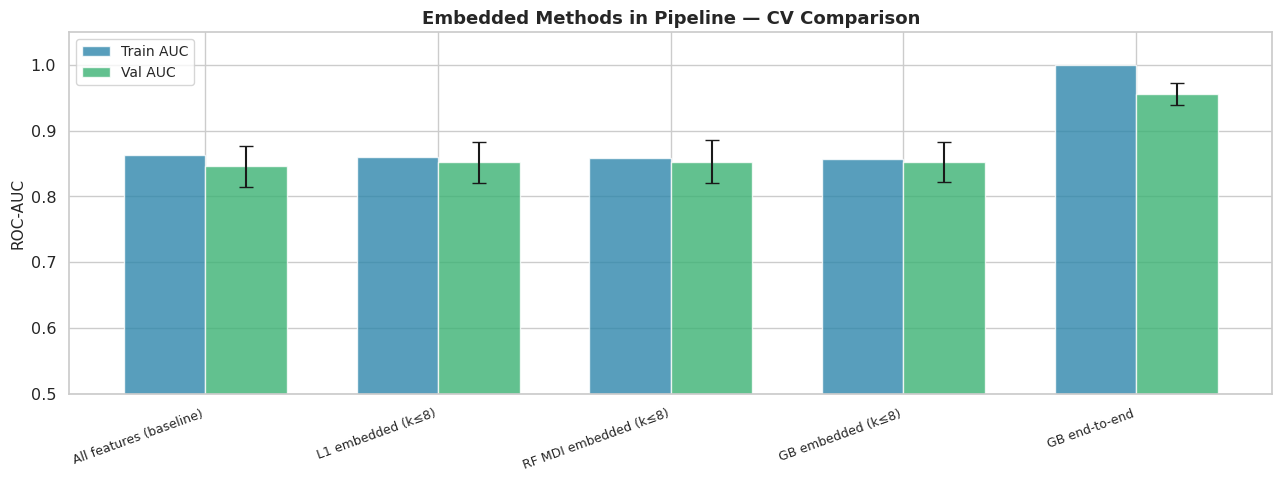

In [13]:
from sklearn.model_selection import cross_validate

X_full = np.vstack([Xc_tr_sc, Xc_te_sc])
y_full = np.concatenate([yc_tr.values, yc_te.values])
skf_p  = StratifiedKFold(5, shuffle=True, random_state=42)

pipe_configs = {
    'All features (baseline)': Pipeline([
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'L1 embedded (k≤8)': Pipeline([
        ('sel', SelectFromModel(
            LogisticRegression(penalty='l1', C=0.3, solver='liblinear', max_iter=1000),
            max_features=8
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'RF MDI embedded (k≤8)': Pipeline([
        ('sel', SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=42),
            max_features=8
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'GB embedded (k≤8)': Pipeline([
        ('sel', SelectFromModel(
            GradientBoostingClassifier(n_estimators=100, random_state=42),
            max_features=8
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'GB end-to-end': Pipeline([
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ]),
}

print('Pipeline CV Results (5-Fold Stratified):')
pipe_rows = []
for name, pipe in pipe_configs.items():
    cv_res = cross_validate(pipe, X_full, y_full, cv=skf_p,
                             scoring='roc_auc', return_train_score=True)
    tr = cv_res['train_score']
    te = cv_res['test_score']
    pipe_rows.append({
        'Pipeline'    : name,
        'Train AUC'   : round(tr.mean(), 4),
        'Val AUC'     : round(te.mean(), 4),
        'Val Std'     : round(te.std(), 4),
        'Overfit Gap' : round(tr.mean() - te.mean(), 4),
    })
    print(f'  {name:35s}: Train={tr.mean():.4f} | Val={te.mean():.4f} ± {te.std():.4f}')

pipe_df = pd.DataFrame(pipe_rows)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(pipe_df))
w = 0.35
ax.bar(x - w/2, pipe_df['Train AUC'], w, label='Train AUC',
       color=COLORS['primary'], alpha=0.8)
ax.bar(x + w/2, pipe_df['Val AUC'],   w, label='Val AUC',
       color=COLORS['accent'], alpha=0.8,
       yerr=pipe_df['Val Std'], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(pipe_df['Pipeline'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_title('Embedded Methods in Pipeline — CV Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.05])
plt.tight_layout()
plt.show()

---
## ✅ 11. Summary & Golden Rules

| Method | Task | Detects Non-Linear | Handles Correlated | sklearn |
|--------|:----:|:-----------------:|:-----------------:|---------|
| **Lasso / LassoCV** | Regression | ❌ | ❌ Picks one | `Lasso`, `LassoCV` |
| **L1 LogReg** | Classification | ❌ | ❌ Picks one | `LogisticRegression(penalty='l1')` |
| **ElasticNet** | Regression | ❌ | ✅ Groups | `ElasticNetCV` |
| **RF MDI** | Both | ✅ | ⚠️ Biased | `RandomForest.feature_importances_` |
| **Permutation Imp** | Both | ✅ | ✅ Corrected | `permutation_importance` |
| **GB MDI** | Both | ✅ | ⚠️ Biased | `GradientBoosting.feature_importances_` |
| **SelectFromModel** | Both | Depends on estimator | Depends | `SelectFromModel` |

### 🔑 Golden Rules

1. **Always use embedded methods inside a Pipeline** — never fit before CV
2. **LassoCV over Lasso** — auto-selects optimal alpha via CV
3. **ElasticNet over Lasso** when features are highly correlated — keeps correlated groups
4. **Permutation Importance over MDI** — corrects high-cardinality and correlation bias
5. **Permutation importance needs a held-out set** — compute on test/validation, not train
6. **Combine embedded + permutation** — use MDI for ranking, permutation for final validation
7. **SelectFromModel threshold='mean'** is a good default — try 'median' for sparser selection
8. **GB and RF give different rankings** — average them for a more stable importance estimate
9. **L1 (Lasso) sets coefficients to exactly zero** — Ridge (L2) never does
10. **Check recovery rate against known ground truth** whenever possible in experiments

---

## 🔗 Next Steps

- ➡️ `06_Feature_Selection/filter_methods.md` — Fast statistical filters
- ➡️ `06_Feature_Selection/wrapper_methods.ipynb` — RFE, Forward/Backward selection
- ➡️ `07_Hyperparameter_Tuning/` — Tune regularization strength (alpha, C) jointly with model
- ➡️ `Ridge_Regression`, `Lasso_Regression` — Embedded selection in regression context
